# Chapter 17: Capstone Projects and Research Challenges

## Hands-On Jupyter Notebook

This notebook frames capstone projects using synthetic backlogs, impact-effort scoring, and delivery-lane planning.

**Time to Complete**: 1-2 hours

---

## Section 1: Setup and Imports

We set up a deterministic project-planning environment for capstone design.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')

# Configuration
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print('Environment configured for Chapter 17 capstone notebook.')

Environment configured for Chapter 17 capstone notebook.


## Section 2: Load Data and Explore

We define a synthetic backlog of capstone ideas with impact, effort, and team-size estimates.

In [2]:
projects_df = pd.DataFrame([
    {'project_id': 'cap_01', 'theme': 'variant triage assistant', 'impact': 5, 'effort': 3, 'team_size': 3},
    {'project_id': 'cap_02', 'theme': 'trial-matching workflow', 'impact': 5, 'effort': 4, 'team_size': 4},
    {'project_id': 'cap_03', 'theme': 'single-cell hotspot explorer', 'impact': 4, 'effort': 3, 'team_size': 2},
    {'project_id': 'cap_04', 'theme': 'governed model review board', 'impact': 4, 'effort': 2, 'team_size': 3},
    {'project_id': 'cap_05', 'theme': 'research roadmap dashboard', 'impact': 3, 'effort': 2, 'team_size': 2},
])
display(projects_df)

,project_id,theme,impact,effort,team_size
0,cap_01,variant triage assistant,5,3,3
1,cap_02,trial-matching workflow,5,4,4
2,cap_03,single-cell hotspot explorer,4,3,2
3,cap_04,governed model review board,4,2,3
4,cap_05,research roadmap dashboard,3,2,2


## Section 3: Main Analysis

We prioritize projects with a simple impact-effort scoring rule and assign delivery lanes.

In [3]:
projects_df['priority_score'] = (projects_df['impact'] * 2) - projects_df['effort']
projects_df['delivery_lane'] = np.where(projects_df['priority_score'] >= 7, 'build_now', np.where(projects_df['priority_score'] >= 5, 'prototype_next', 'backlog'))
project_summary = projects_df.groupby('delivery_lane', as_index=False).agg(projects=('project_id', 'count'), avg_score=('priority_score', 'mean'))
project_summary['avg_score'] = project_summary['avg_score'].round(2)
display(projects_df.sort_values('priority_score', ascending=False))
display(project_summary)

,project_id,theme,impact,effort,team_size,priority_score,delivery_lane
0,cap_01,variant triage assistant,5,3,3,7,build_now
1,cap_02,trial-matching workflow,5,4,4,6,prototype_next
3,cap_04,governed model review board,4,2,3,6,prototype_next
2,cap_03,single-cell hotspot explorer,4,3,2,5,prototype_next
4,cap_05,research roadmap dashboard,3,2,2,4,backlog


,delivery_lane,projects,avg_score
0,backlog,1,4.00
1,build_now,1,7.00
2,prototype_next,3,5.67


## Section 4: Visualization

We visualize capstone priority and the effort-impact tradeoff landscape.

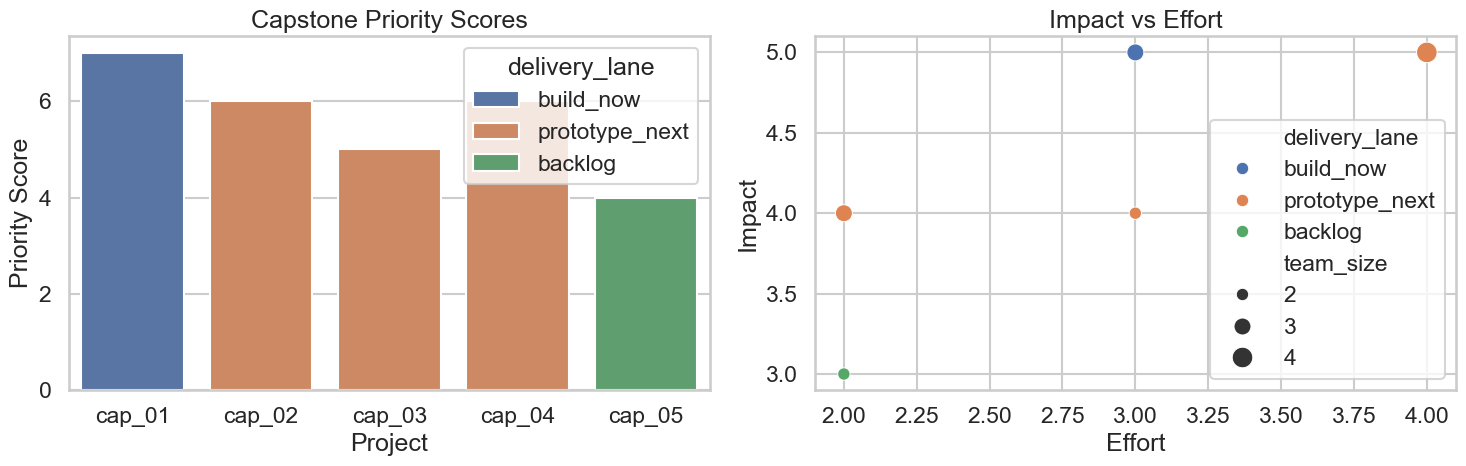

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=projects_df, x='project_id', y='priority_score', hue='delivery_lane', ax=axes[0])
axes[0].set_title('Capstone Priority Scores')
axes[0].set_xlabel('Project')
axes[0].set_ylabel('Priority Score')

sns.scatterplot(data=projects_df, x='effort', y='impact', hue='delivery_lane', size='team_size', sizes=(80, 220), ax=axes[1])
axes[1].set_title('Impact vs Effort')
axes[1].set_xlabel('Effort')
axes[1].set_ylabel('Impact')

plt.tight_layout()
plt.show()

## Section 5: Exercises

### Exercise 1: Project Selection

*Description: Select the top two projects for immediate prototype work.*

In [5]:
top_projects = projects_df.sort_values('priority_score', ascending=False).head(2)
display(top_projects[['project_id', 'theme', 'priority_score', 'delivery_lane']])

,project_id,theme,priority_score,delivery_lane
0,cap_01,variant triage assistant,7,build_now
1,cap_02,trial-matching workflow,6,prototype_next


### Exercise 2: Delivery Plan

*Description: Draft a short delivery plan sentence for each project.*

In [6]:
plan_rows = []
for _, row in projects_df.iterrows():
    plan_rows.append({'project_id': row['project_id'], 'delivery_plan': f"{row['delivery_lane']} with {row['team_size']} contributors"})
plan_df = pd.DataFrame(plan_rows)
display(plan_df)

,project_id,delivery_plan
0,cap_01,build_now with 3 contributors
1,cap_02,prototype_next with 4 contributors
2,cap_03,prototype_next with 2 contributors
3,cap_04,prototype_next with 3 contributors
4,cap_05,backlog with 2 contributors


## Section 6: Key Takeaways

- Capstones should be prioritized with explicit impact-effort logic.
- Delivery lanes help teams decide what to build now versus later.
- Lightweight planning artifacts improve project execution clarity.

---

## Next Steps

1. ✅ Complete all exercises
2. 📖 Revisit chapters that support your selected capstone architecture
3. 🔗 Review related chapters as needed
4. 🧪 Adapt the capstone rubric to your own project ideas

---

**Last Updated**: May 2026